## Convert the data into a classification model injestable format

In [3]:
import json
from params.paths import DATA_DIR
import os
import re

PARLIAMENT_SPEECH_LABELS = [
	"質問文",
	"追及・確認文",
	"答弁文",
	"反論・再反論文",
	"意見文",
	"要望・提案文",
	"批判文",
	"評価文",
	"説明文",
	"事実文",
	"謝罪・釈明文",
	"手続・運営文",
	"その他"
]

YOUTUBE_SPEECH_LABELS = [
	"政治",
	"その他",
	"質問文",
	"追及・確認文",
	"答弁文",
	"反論・再反論文",
	"意見文",
	"要望・提案文",
	"批判文",
	"評価文",
	"説明文",
	"事実文",
	"謝罪・釈明文",
	"手続・運営文",
]

TWITTER_SPEECH_LABELS = [
	"政治",
	"趣味",
	"挨拶",
	"その他"
]

TEXT_FIELDS = [
	"speech",
	"text",
	"tweet"
]

LABEL_FIELDS = [
	"label",
	"labels",
	"label"
]

PARLIAMENT_DATA_PATH = os.path.join(DATA_DIR, "diet_speech_label", "segment_diet_speech_label.jsonl")
YOUTUBE_DATA_PATH = os.path.join(DATA_DIR, "youtube_label", "youtube_label_processed.jsonl")
TWITTER_DATA_PATH = os.path.join(DATA_DIR, "tweet_label", "tweet_label.jsonl")
for path in [PARLIAMENT_DATA_PATH, YOUTUBE_DATA_PATH, TWITTER_DATA_PATH]:
	if not os.path.exists(path):
		raise FileNotFoundError(f"Required data file not found: {path}")

PARLIAMENT_DATA_PROCESSED_PATH = os.path.join(DATA_DIR, "diet_speech_label", "vector_label_diet_speech_label.jsonl")
YOUTUBE_DATA_PROCESSED_PATH = os.path.join(DATA_DIR, "youtube_label", "vector_label_youtube_label.jsonl")
TWITTER_DATA_PROCESSED_PATH = os.path.join(DATA_DIR, "tweet_label", "vector_label_tweet_label.jsonl")

IGNORE_DATA = ["parliament", "twitter"]


def add_periods(text: str) -> str:
	"""Insert Japanese periods after sentence-ending phrases.

	- Adds "。" after any occurrence of the end words.
	- Does NOT add if it's already followed by punctuation like "。", "！", "？".
	"""
	end_words = ["ですね", "ですよ", "である", "です", "ます"]
	pattern = "(" + "|".join(re.escape(w) for w in end_words) + ")"
	# Replace end-word occurrences not already followed by punctuation.
	return re.sub(pattern + r"(?![。！？!?])", r"\1。", text)

def convert_labels_to_vector():
	for data_type, path, labels, processed_path, text_field, label_field in (
		('parliament', PARLIAMENT_DATA_PATH, PARLIAMENT_SPEECH_LABELS, PARLIAMENT_DATA_PROCESSED_PATH, TEXT_FIELDS[0], LABEL_FIELDS[0]),
		('youtube', YOUTUBE_DATA_PATH, YOUTUBE_SPEECH_LABELS, YOUTUBE_DATA_PROCESSED_PATH, TEXT_FIELDS[1], LABEL_FIELDS[1]),
		('twitter', TWITTER_DATA_PATH, TWITTER_SPEECH_LABELS, TWITTER_DATA_PROCESSED_PATH, TEXT_FIELDS[2], LABEL_FIELDS[2]),
	):
		print(f"Processing {path} into {processed_path}...")
		if data_type in IGNORE_DATA:
			print(f"Skipping {data_type} data as per configuration.")
			continue
		with open(path, "r", encoding="utf-8") as f_in, open(processed_path, "w", encoding="utf-8") as f_out:
			for line in f_in:
				data = json.loads(line)
				data_text = data[text_field]
				if data_type == "youtube":
					data_text = add_periods(data_text)



				data_labels = data[label_field]
				if type(data_labels) == str:
					data_labels = [data_labels]
						
				label_vector = [0] * len(labels)
				for data_label in data_labels:
					if data_label in labels:
						label_index = labels.index(data_label)
						label_vector[label_index] = 1

				if sum(label_vector) == 0:
					continue
					
				processed_data = {
					"text": data_text,
					"label": label_vector,
					"text_label": data_labels
				}
				f_out.write(json.dumps(processed_data, ensure_ascii=False) + "\n")



convert_labels_to_vector()


Processing /root/projects/kokkai_analysis/data/params/../data/diet_speech_label/segment_diet_speech_label.jsonl into /root/projects/kokkai_analysis/data/params/../data/diet_speech_label/vector_label_diet_speech_label.jsonl...
Skipping parliament data as per configuration.
Processing /root/projects/kokkai_analysis/data/params/../data/youtube_label/youtube_label_processed.jsonl into /root/projects/kokkai_analysis/data/params/../data/youtube_label/vector_label_youtube_label.jsonl...
Processing /root/projects/kokkai_analysis/data/params/../data/tweet_label/tweet_label.jsonl into /root/projects/kokkai_analysis/data/params/../data/tweet_label/vector_label_tweet_label.jsonl...
Skipping twitter data as per configuration.


## Train classifier on the labelled data

In [4]:
import numpy as np
from datasets import Dataset, Sequence, Value
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import evaluate
from peft import LoraConfig, get_peft_model, TaskType
import torch
import random
import matplotlib.pyplot as plt


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

MODEL_NAME = "ku-nlp/deberta-v3-base-japanese"

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib


def plot_label_distribution_hf(ds, labels, split="train", label_col="labels", top_k=None, log_y=False):
    """
    Plot label frequency distribution for a HuggingFace Dataset / DatasetDict.

    Args:
        ds: datasets.Dataset or datasets.DatasetDict
        labels (list[str]): label names in index order
        split (str): which split to use if ds is a DatasetDict (e.g., "train")
        label_col (str): column that contains the multi-hot / multi-label vector (e.g., "labels")
        top_k (int|None): if set, plot only the top-k most frequent labels
        log_y (bool): whether to use log scale on y axis
    """
    d = ds[split] if isinstance(ds, dict) or hasattr(ds, "keys") else ds

    if label_col not in d.column_names:
        raise ValueError(f"'{label_col}' not in dataset columns: {d.column_names}")

    # Efficient: pull the whole column once
    y = d[label_col]  # list[list[float|int]] or list[np.array]
    y = np.asarray(y)

    # Handle float labels (0.0/1.0) safely
    y = (y > 0.5).astype(np.int64)

    if y.ndim != 2 or y.shape[1] != len(labels):
        raise ValueError(
            f"Expected '{label_col}' to be shape [N, {len(labels)}], got {y.shape}"
        )

    label_counts = y.sum(axis=0)
    total_samples = y.shape[0]

    # Sort
    sorted_idx = np.argsort(label_counts)[::-1]
    sorted_counts = label_counts[sorted_idx]
    sorted_labels = [labels[i] for i in sorted_idx]

    if top_k is not None:
        sorted_counts = sorted_counts[:top_k]
        sorted_labels = sorted_labels[:top_k]

    print(f"Split: {split} | Total samples: {total_samples}")
    for lab, c in zip(sorted_labels, sorted_counts):
        print(f"{lab}: {int(c)}")

    # Plot
    fig_w = max(10, len(sorted_labels) * 0.4)
    plt.figure(figsize=(fig_w, 6))
    plt.bar(sorted_labels, sorted_counts)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of samples")
    plt.xlabel("Labels")
    plt.title(f"Label Distribution (Multi-label) — {split}")
    if log_y:
        plt.yscale("log")
        plt.ylabel("Number of samples (log scale)")
    plt.tight_layout()
    plt.show()


Split: train | Total samples: 2995
意見文: 835
説明文: 680
質問文: 586
事実文: 551
要望・提案文: 256
手続・運営文: 253
その他: 181
批判文: 138
追及・確認文: 67
答弁文: 61
評価文: 30
謝罪・釈明文: 7
反論・再反論文: 2


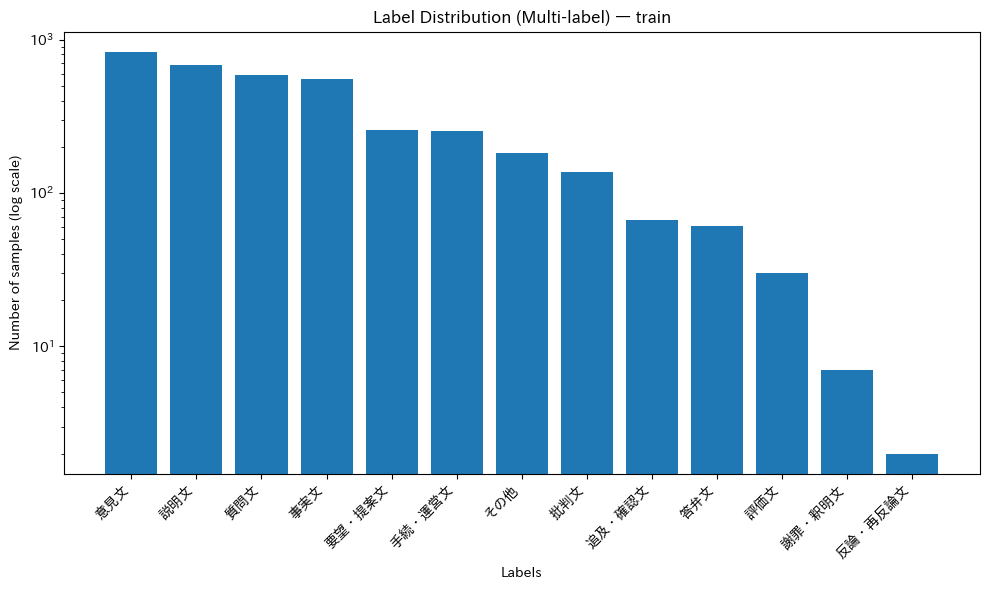

Split: train | Total samples: 1333
政治: 1231
意見文: 1166
要望・提案文: 886
説明文: 639
質問文: 594
批判文: 592
答弁文: 312
事実文: 240
評価文: 204
追及・確認文: 142
その他: 132
手続・運営文: 47
謝罪・釈明文: 41
反論・再反論文: 13


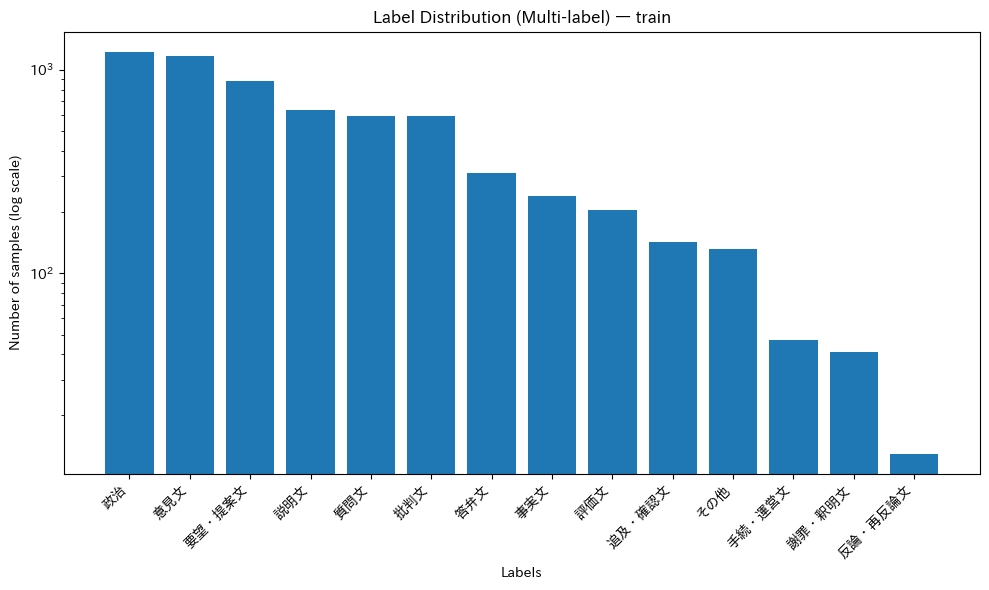

Split: train | Total samples: 8696
政治: 5352
その他: 2528
趣味: 750
挨拶: 66


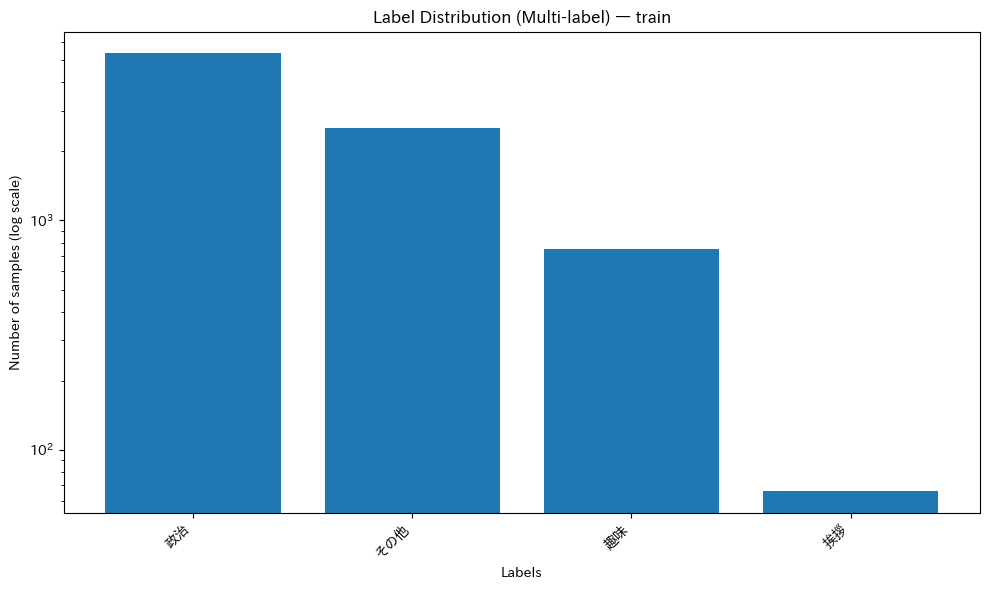

In [18]:
for path in [PARLIAMENT_DATA_PROCESSED_PATH, YOUTUBE_DATA_PROCESSED_PATH, TWITTER_DATA_PROCESSED_PATH]:
	if not os.path.exists(path):
	 	raise FileNotFoundError(f"Processed data file not found: {path}")
	plot_label_distribution_hf(
		Dataset.from_json(path),
		labels=PARLIAMENT_SPEECH_LABELS if "diet_speech" in path else YOUTUBE_SPEECH_LABELS if "youtube" in path else TWITTER_SPEECH_LABELS,
		split="train",
		label_col="label",
		log_y=True,
	)

## First for the parliament data

In [ ]:
ds = Dataset.from_json(PARLIAMENT_DATA_PROCESSED_PATH).train_test_split(test_size=0.2, seed=42)

ds = ds.rename_column("label", "labels")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False, trust_remote_code=False)

def tok(batch):
	tok = tokenizer(batch['text'], truncation=True)
	tok['labels'] = [[float(x) for x in y] for y in batch['labels']]
	return tok

ds = ds.map(tok, batched=True, remove_columns=["text", "text_label"])

features = ds["train"].features.copy()
features["labels"] = Sequence(Value("float32"), length=len(PARLIAMENT_SPEECH_LABELS))  # length optional but nice
ds = ds.cast(features)


model = AutoModelForSequenceClassification.from_pretrained(
	MODEL_NAME,
	num_labels=len(PARLIAMENT_SPEECH_LABELS),
	device_map="auto",
)

model.config.problem_type = "multi_label_classification"

lora_config = LoraConfig(
	task_type=TaskType.SEQ_CLS,
	r=8,
	lora_alpha=16,
	lora_dropout=0.05,
	init_lora_weights="gaussian",
	bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

args = TrainingArguments(
	output_dir=os.path.join(DATA_DIR, "finetuned_text_labeller_parliament"),
	learning_rate=2e-5,
	per_device_train_batch_size=16,
	per_device_eval_batch_size=32,
	num_train_epochs=20,
	eval_strategy="epoch",
)

f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

# Optional but very useful for multi-label:
# pip install scikit-learn
from sklearn.metrics import average_precision_score

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

LABELS = PARLIAMENT_SPEECH_LABELS
num_labels = len(LABELS)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid(logits)

    thr = 0.5
    preds = (probs >= thr).astype(np.int32)

    # make sure labels are 0/1 ints (yours are float32)
    y_true = (labels >= 0.5).astype(np.int32)

    out = {
        "f1_micro": f1_score(y_true, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, preds, average="macro", zero_division=0),
        "precision_micro": precision_score(y_true, preds, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, preds, average="micro", zero_division=0),
        "pr_auc_macro": average_precision_score(y_true, probs, average="macro"),
    }

    # per-label f1
    per_label = f1_score(y_true, preds, average=None, zero_division=0)
    for i, v in enumerate(per_label):
        out[f"f1_{LABELS[i]}"] = float(v)

    return out



trainer = Trainer(
	model=model,
	args=args,
	train_dataset=ds["train"],
	eval_dataset=ds["test"],
	tokenizer=tokenizer,
	compute_metrics=compute_metrics,
)

trainer.train()

metrics = trainer.evaluate()
print(metrics)

from sklearn.metrics import f1_score
pred = trainer.predict(ds["test"])
logits = pred.predictions
labels = pred.label_ids
probs = 1 / (1 + np.exp(-logits))


best_thr, best_f1 = None, -1
for thr in np.linspace(0.05, 0.95, 19):
    preds = (probs >= thr).astype(int)
    f1_micro = f1_score(labels, preds, average="micro")
    if f1_micro > best_f1:
        best_f1, best_thr = f1_micro, thr

print("best_thr", best_thr, "best_f1_micro", best_f1)

import datetime
datetime_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
trainer.save_model(os.path.join(DATA_DIR, f"finetuned_text_labeller_parliament/{datetime_str}/"))




Casting the dataset: 100%|██████████| 599/599 [00:00<00:00, 71334.13 examples/s]
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at ku-nlp/deberta-v3-base-japanese and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 304,909 || all params: 160,775,450 || trainable%: 0.1896


/tmp/ipykernel_10783/1469398694.py:91: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 96868, 'bos_token_id': 96871, 'pad_token_id': 96869}.


Epoch,Training Loss,Validation Loss


## Youtube data labelling

In [ ]:
ds = Dataset.from_json(YOUTUBE_DATA_PROCESSED_PATH).train_test_split(test_size=0.2, seed=42)

ds = ds.rename_column("label", "labels")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok(batch):
	tok = tokenizer(batch['text'], truncation=True)
	tok['labels'] = [[float(x) for x in y] for y in batch['labels']]
	return tok

ds = ds.map(tok, batched=True, remove_columns=["text", "text_label"])

features = ds["train"].features.copy()
features["labels"] = Sequence(Value("float32"), length=len(YOUTUBE_SPEECH_LABELS))  # length optional but nice
ds = ds.cast(features)


model = AutoModelForSequenceClassification.from_pretrained(
	MODEL_NAME,
	num_labels=len(YOUTUBE_SPEECH_LABELS),
)

model.config.problem_type = "multi_label_classification"

lora_config = LoraConfig(
	task_type=TaskType.SEQ_CLS,
	r=5,
	lora_alpha=16,
	lora_dropout=0.05,
	init_lora_weights="gaussian",
	bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

args = TrainingArguments(
	output_dir=os.path.join(DATA_DIR, "finetuned_text_labeller_youtube"),
	learning_rate=2e-5,
	per_device_train_batch_size=8,
	per_device_eval_batch_size=16,
	num_train_epochs=20,
	eval_strategy="epoch",
)

f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

# Optional but very useful for multi-label:
# pip install scikit-learn
from sklearn.metrics import average_precision_score

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

LABELS = YOUTUBE_SPEECH_LABELS
num_labels = len(LABELS)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid(logits)

    thr = 0.5
    preds = (probs >= thr).astype(np.int32)

    # make sure labels are 0/1 ints (yours are float32)
    y_true = (labels >= 0.5).astype(np.int32)

    out = {
        "f1_micro": f1_score(y_true, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, preds, average="macro", zero_division=0),
        "precision_micro": precision_score(y_true, preds, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, preds, average="micro", zero_division=0),
        "pr_auc_macro": average_precision_score(y_true, probs, average="macro"),
    }

    # per-label f1
    per_label = f1_score(y_true, preds, average=None, zero_division=0)
    for i, v in enumerate(per_label):
        out[f"f1_{LABELS[i]}"] = float(v)

    return out



trainer = Trainer(
	model=model,
	args=args,
	train_dataset=ds["train"],
	eval_dataset=ds["test"],
	tokenizer=tokenizer,
	compute_metrics=compute_metrics,
)

trainer.train()

metrics = trainer.evaluate()
print(metrics)

from sklearn.metrics import f1_score
pred = trainer.predict(ds["test"])
logits = pred.predictions
labels = pred.label_ids
probs = 1 / (1 + np.exp(-logits))


best_thr, best_f1 = None, -1
for thr in np.linspace(0.05, 0.95, 19):
    preds = (probs >= thr).astype(int)
    f1_micro = f1_score(labels, preds, average="micro")
    if f1_micro > best_f1:
        best_f1, best_thr = f1_micro, thr

print("best_thr", best_thr, "best_f1_micro", best_f1)

import datetime
datetime_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
trainer.save_model(os.path.join(DATA_DIR, f"finetuned_text_labeller_youtube/{datetime_str}/"))



Casting the dataset: 100%|██████████| 267/267 [00:00<00:00, 46373.73 examples/s]
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at ku-nlp/deberta-v3-base-japanese and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 195,086 || all params: 160,666,396 || trainable%: 0.1214


/tmp/ipykernel_2236/1589795342.py:90: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 96868, 'bos_token_id': 96871, 'pad_token_id': 96869}.


RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript (most recent call last):
  File "/root/projects/kokkai_analysis/data/data_venv/lib/python3.14/site-packages/transformers/models/deberta_v2/modeling_deberta_v2.py", line 59, in make_log_bucket_position
@torch.jit.script
def make_log_bucket_position(relative_pos, bucket_size: int, max_position: int):
    sign = torch.sign(relative_pos)
           ~~~~~~~~~~ <--- HERE
    mid = bucket_size // 2
    abs_pos = torch.where(
RuntimeError: CUDA out of memory. Tried to allocate 4.05 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 37.58 GiB is allocated by PyTorch, and 49.11 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Mem

## Traininng classifier for twitter data

In [ ]:
ds = Dataset.from_json(TWITTER_DATA_PROCESSED_PATH).train_test_split(test_size=0.2, seed=42)

ds = ds.rename_column("label", "labels")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok(batch):
	tok = tokenizer(batch['text'], truncation=True)
	tok['labels'] = [[float(x) for x in y] for y in batch['labels']]
	return tok

ds = ds.map(tok, batched=True, remove_columns=["text", "text_label"])

features = ds["train"].features.copy()
features["labels"] = Sequence(Value("float32"), length=len(TWITTER_SPEECH_LABELS))  # length optional but nice
ds = ds.cast(features)


model = AutoModelForSequenceClassification.from_pretrained(
	MODEL_NAME,
	num_labels=len(TWITTER_SPEECH_LABELS),
	device_map="auto",
)

model.config.problem_type = "multi_label_classification"

lora_config = LoraConfig(
	task_type=TaskType.SEQ_CLS,
	r=8,
	lora_alpha=16,
	lora_dropout=0.05,
	init_lora_weights="gaussian",
	bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

args = TrainingArguments(
	output_dir=os.path.join(DATA_DIR, "finetuned_text_labeller_twitter"),
	learning_rate=2e-5,
	per_device_train_batch_size=16,
	per_device_eval_batch_size=32,
	num_train_epochs=20,
	eval_strategy="epoch",
)

f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

# Optional but very useful for multi-label:
# pip install scikit-learn
from sklearn.metrics import average_precision_score

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

LABELS = TWITTER_SPEECH_LABELS
num_labels = len(LABELS)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid(logits)

    thr = 0.5
    preds = (probs >= thr).astype(np.int32)

    # make sure labels are 0/1 ints (yours are float32)
    y_true = (labels >= 0.5).astype(np.int32)

    out = {
        "f1_micro": f1_score(y_true, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, preds, average="macro", zero_division=0),
        "precision_micro": precision_score(y_true, preds, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, preds, average="micro", zero_division=0),
        "pr_auc_macro": average_precision_score(y_true, probs, average="macro"),
    }

    # per-label f1
    per_label = f1_score(y_true, preds, average=None, zero_division=0)
    for i, v in enumerate(per_label):
        out[f"f1_{LABELS[i]}"] = float(v)

    return out



trainer = Trainer(
	model=model,
	args=args,
	train_dataset=ds["train"],
	eval_dataset=ds["test"],
	tokenizer=tokenizer,
	compute_metrics=compute_metrics,
)

trainer.train()

metrics = trainer.evaluate()
print(metrics)

from sklearn.metrics import f1_score
pred = trainer.predict(ds["test"])
logits = pred.predictions
labels = pred.label_ids
probs = 1 / (1 + np.exp(-logits))


best_thr, best_f1 = None, -1
for thr in np.linspace(0.05, 0.95, 19):
    preds = (probs >= thr).astype(int)
    f1_micro = f1_score(labels, preds, average="micro")
    if f1_micro > best_f1:
        best_f1, best_thr = f1_micro, thr

print("best_thr", best_thr, "best_f1_micro", best_f1)

import datetime
datetime_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
trainer.save_model(os.path.join(DATA_DIR, f"finetuned_text_labeller_twitter/{datetime_str}/"))



Casting the dataset: 100%|██████████| 1740/1740 [00:00<00:00, 217101.65 examples/s]
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at ku-nlp/deberta-v3-base-japanese and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 297,988 || all params: 160,761,608 || trainable%: 0.1854


/tmp/ipykernel_30035/1827006503.py:91: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 96868, 'bos_token_id': 96871, 'pad_token_id': 96869}.


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Precision Micro,Recall Micro,Pr Auc Macro,F1 政治,F1 趣味,F1 挨拶,F1 その他
1,No log,0.382676,0.624771,0.197455,0.665800,0.588506,0.423624,0.789819,0.000000,0.000000,0.000000
2,0.456000,0.260931,0.781379,0.395172,0.801693,0.762069,0.528813,0.902148,0.000000,0.000000,0.678540
3,0.302000,0.248792,0.783143,0.390254,0.797853,0.768966,0.549314,0.908345,0.000000,0.000000,0.652672
4,0.253000,0.235818,0.796280,0.404496,0.805409,0.787356,0.567269,0.912713,0.000000,0.000000,0.705272
5,0.238600,0.236383,0.796748,0.402610,0.805164,0.788506,0.572041,0.913225,0.000000,0.000000,0.697215
6,0.220400,0.239831,0.793273,0.416751,0.800468,0.786207,0.578004,0.912746,0.081395,0.000000,0.672862
7,0.218600,0.226764,0.811685,0.505398,0.801232,0.822414,0.583987,0.915628,0.385965,0.000000,0.720000
8,0.218600,0.218175,0.805262,0.456207,0.801366,0.809195,0.586917,0.918483,0.193878,0.000000,0.712468
9,0.213300,0.223106,0.818259,0.527594,0.802653,0.834483,0.585668,0.918970,0.479339,0.000000,0.712069
10,0.212200,0.219077,0.822905,0.550897,0.800543,0.846552,0.587455,0.919476,0.571429,0.000000,0.712683


{'eval_loss': 0.2128942906856537, 'eval_f1_micro': 0.8307957483481758, 'eval_f1_macro': 0.564295175902024, 'eval_precision_micro': 0.8305571510626077, 'eval_recall_micro': 0.8310344827586207, 'eval_pr_auc_macro': 0.594189630436155, 'eval_f1_政治': 0.9179245283018868, 'eval_f1_趣味': 0.6109324758842444, 'eval_f1_挨拶': 0.0, 'eval_f1_その他': 0.7283236994219653, 'eval_runtime': 34.2368, 'eval_samples_per_second': 50.822, 'eval_steps_per_second': 1.606, 'epoch': 20.0}
best_thr 0.49999999999999994 best_f1_micro 0.8307957483481758


## Upload to Huggingface Hub

In [ ]:
import os
from transformers import AutoConfig
from huggingface_hub import create_repo, upload_folder
from params.paths import DATA_DIR



BASE_MODEL = "ku-nlp/deberta-v3-base-japanese"  # <--


REPO_NAMES = [
    "text_labeller_parliament-deberta-v3-base-japanese",
    "text_labeller_twitter-deberta-v3-base-japanese",
]

DIRECTORIES = [
    "finetuned_text_labeller_parliament/checkpoint-3000/",
    "finetuned_text_labeller_twitter/checkpoint-8700/",
]

REPO_ID = "kkatodus"

PARLIAMENT_SPEECH_LABELS = [
    "質問文",
    "追及・確認文",
    "答弁文",
    "反論・再反論文",
    "意見文",
    "要望・提案文",
    "批判文",
    "評価文",
    "説明文",
    "事実文",
    "謝罪・釈明文",
    "手続・運営文",
    "その他"
]

TWITTER_SPEECH_LABELS = [
    "政治",
    "趣味",
    "挨拶",
    "その他"
]

LABELS_LIST = [PARLIAMENT_SPEECH_LABELS, TWITTER_SPEECH_LABELS]

for repo_name, ckpt_dir, labels in zip(REPO_NAMES, DIRECTORIES, LABELS_LIST):
    local_path = os.path.join(DATA_DIR, ckpt_dir)

    id2label = {i: label for i, label in enumerate(labels)}
    label2id = {label: i for i, label in enumerate(labels)}
    # 1️⃣ Load config
    config = AutoConfig.from_pretrained(BASE_MODEL)

    # 2️⃣ Inject label metadata
    config.id2label = id2label
    config.label2id = label2id
    config.num_labels = len(labels)
    config.problem_type = "multi_label_classification"

    # 3️⃣ Save config back (this updates config.json)
    config.save_pretrained(local_path)

    # 4️⃣ Create repo + upload
    create_repo(repo_id=f"{REPO_ID}/{repo_name}", exist_ok=True)

    upload_folder(
        repo_id=f"{REPO_ID}/{repo_name}",
        folder_path=local_path,
        repo_type="model",
    )

Processing Files (6 / 6): 100%|██████████| 5.39MB / 5.39MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Processing Files (5 / 5): 100%|██████████| 3.65MB / 3.65MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
